### 1. PROBLEM STATEMENT

The goal is to build a machine learning model to detect fraudulent banking transactions using features like transaction patterns, account behavior, and risk indicators. Fraud detection is challenging because:

Class imbalance: Fraud cases are rare .

Subtle patterns: Fraud transactions may closely resemble normal ones.

High cost of errors: Missing a fraud (false negative) is worse than falsely flagging a normal transaction (false positive).

### 2. LOAD LIBRARIES AND DATA

In [21]:
import warnings
import itertools
import random

#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mn

In [22]:
fraud=pd.read_csv("FraudShield_Banking_Data.csv")
fraud.head()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


Understanding the Data

In [23]:
fraud.shape

(50000, 25)

In [5]:
fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  str    
 4   Transaction_Date                       49997 non-null  str    
 5   Transaction_Type                       49996 non-null  str    
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  str    
 8   Transaction_Location                   49994 non-null  str    
 9   Customer_Home_Location                 49996 non-null  str    
 10  Distance_From_Home                     49998 non-null  float64
 11  Device_ID    

In [ ]:
#Removing irrelevant columns
#The ID'S columnS  are irrelevant.They have no predictive patterns and removing them prevents noise and increases the models performance.
fraud =fraud.drop(columns=[
"Transaction_ID",
"Customer_ID",
"Merchant_ID",
"Device_ID",
"IP_Address"
])

### Cleaning Target Variable

In [25]:
fraud.isnull().sum().sort_values(ascending=False)

Failed_Transaction_Count                 11
Transaction_Amount (in Million)           9
Merchant_Category                         9
Transaction_Time                          9
Avg_Transaction_Amount (in Million)       9
Account_Balance (in Million)              9
Daily_Transaction_Count                   9
Transaction_Location                      6
Weekly_Transaction_Count                  5
Is_New_Merchant                           5
Is_International_Transaction              4
Transaction_Type                          4
Customer_Home_Location                    4
Fraud_Label                               4
Max_Transaction_Last_24h (in Million)     4
Transaction_Date                          3
Unusual_Time_Transaction                  3
Card_Type                                 3
Previous_Fraud_Count                      3
Distance_From_Home                        2
dtype: int64

In [26]:
fraud.dropna(subset=['Fraud_Label'], inplace=True)

In [27]:
# Convert target to numeric
y = fraud['Fraud_Label'].map({'Fraud': 1, 'Normal': 0})
X = fraud.drop('Fraud_Label', axis=1)

In [28]:
# Convert time
X['Transaction_Date'] = pd.to_datetime(X['Transaction_Date'])
X['Transaction_Time'] = pd.to_datetime(X['Transaction_Time'])

C:\Users\mburu\AppData\Local\Temp\ipykernel_26336\2364772293.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['Transaction_Time'] = pd.to_datetime(X['Transaction_Time'])


LINEAR SEPARABILITY

I picked some few meaningful features because plotting all of them became messy

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select key numerical features
features = [
    "Transaction_Amount (in Million)",
    "Avg_Transaction_Amount (in Million)",
    "Daily_Transaction_Count",
    "Distance_From_Home",
    "Account_Balance (in Million)"
]

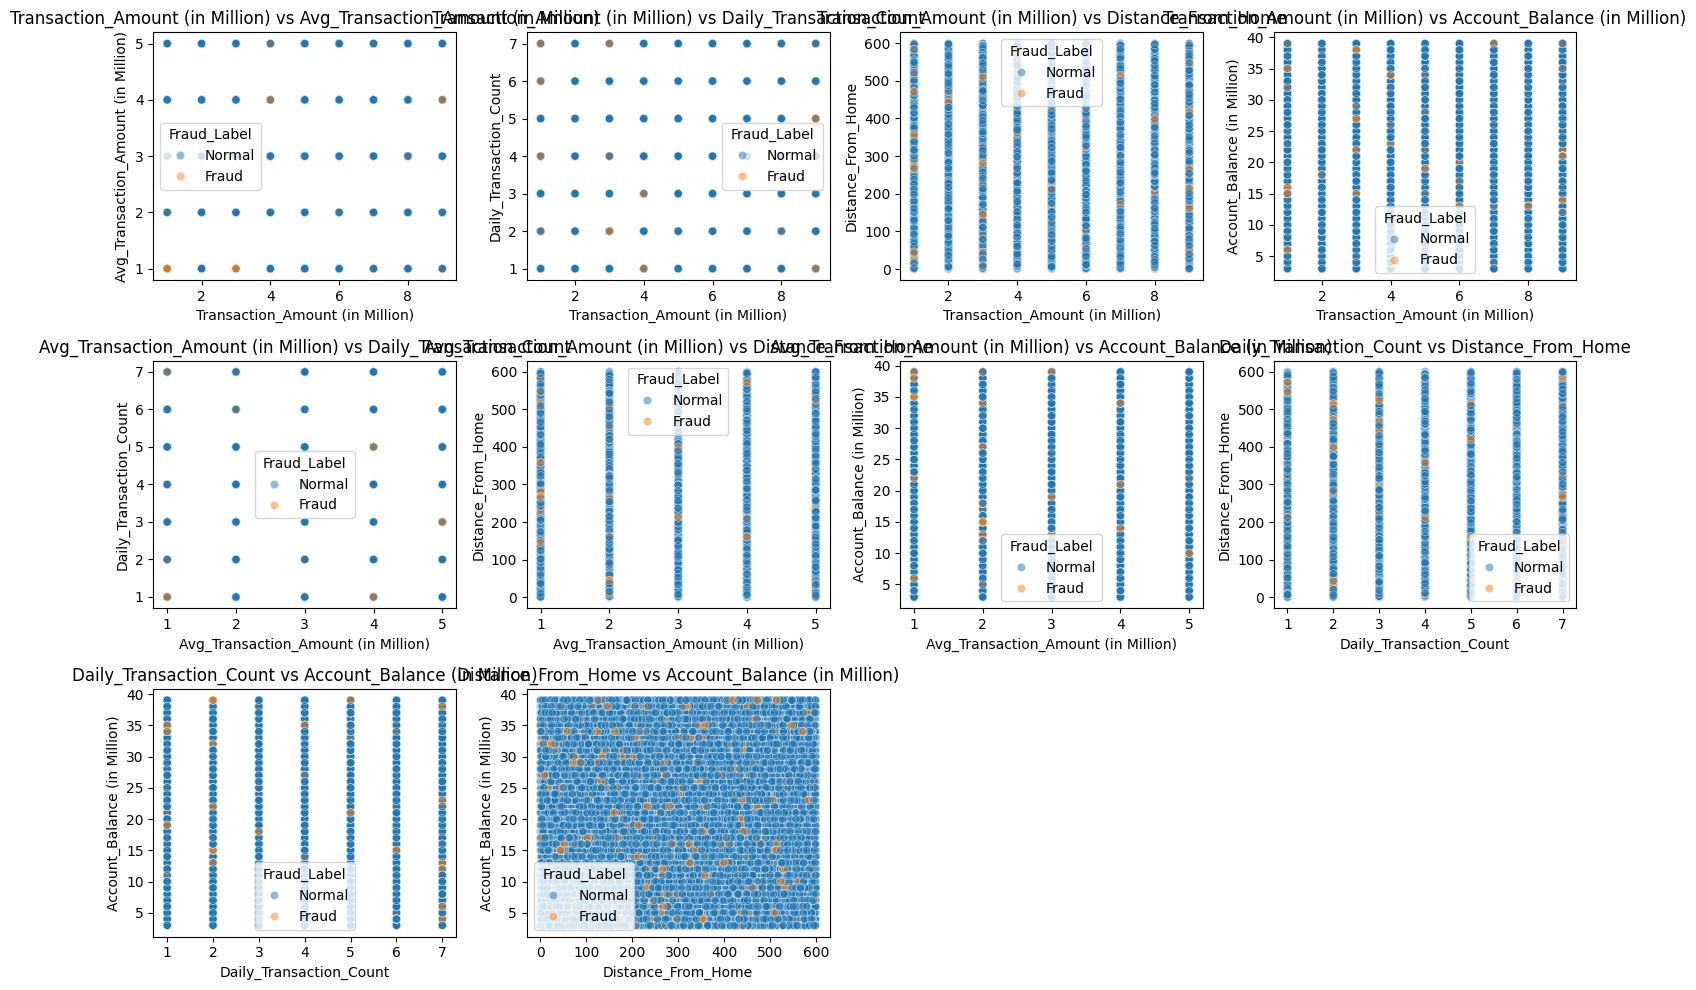

In [84]:
plt.figure(figsize=(15,10))

plot_num = 1

for i in range(len(features)):
    for j in range(i+1, len(features)):
        
        plt.subplot(3, 4, plot_num)
        
        sns.scatterplot(
            x=fraud[features[i]],
            y=fraud[features[j]],
            hue=fraud['Fraud_Label'],
            alpha=0.5
        )
        
        plt.xlabel(features[i])
        plt.ylabel(features[j])
        plt.title(f"{features[i]} vs {features[j]}")
        
        plot_num += 1

plt.tight_layout()
plt.show()

 I used scatter plot subplots of key features to check linear separability. The fraud and normal transactions showed significant overlap, meaning the data is not linearly separable. Therefore, I selected non-linear models like Random Forest, which can capture complex patterns

OUTLIERS

In [13]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

C:\Users\mburu\AppData\Local\Temp\ipykernel_26336\197916445.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


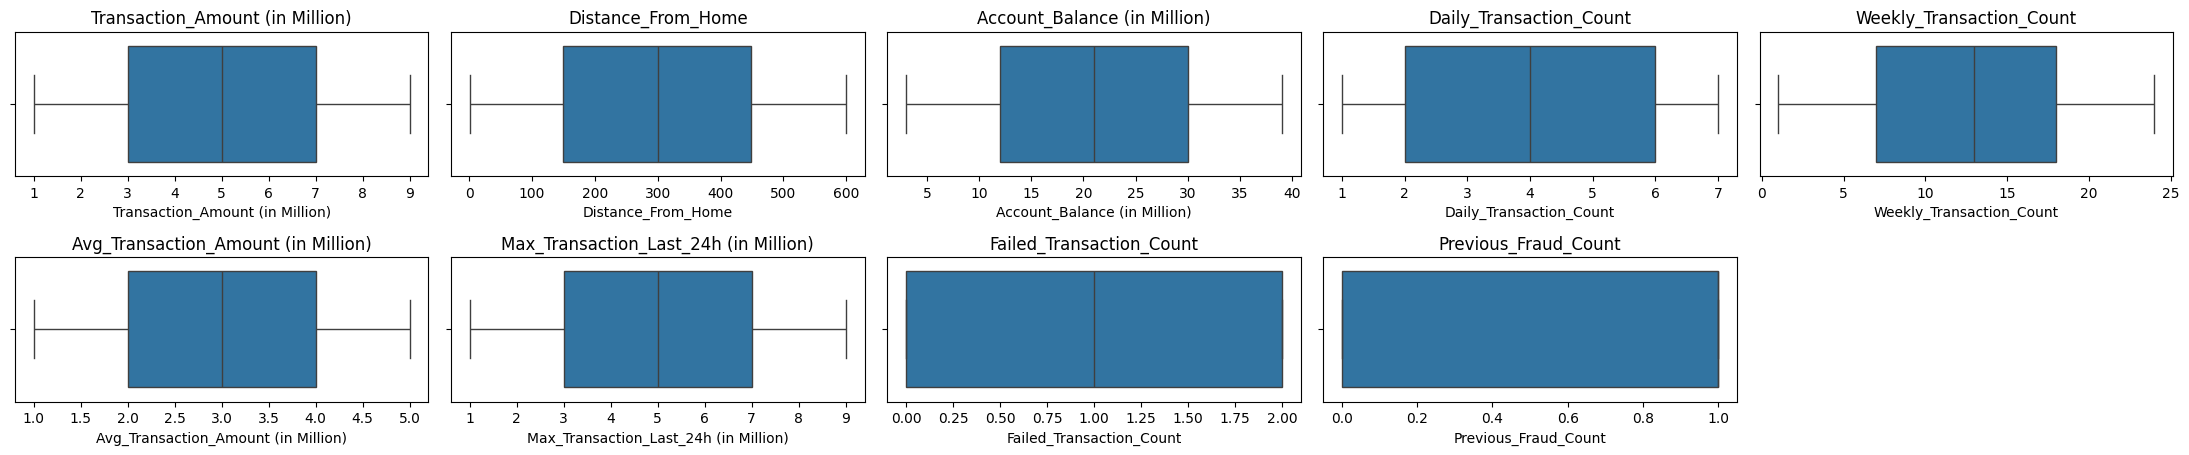

In [29]:
fig = plt.figure(figsize=(22,20))

for i in range(len(num_cols)):
    ax = fig.add_subplot(9, 5, i+1)
    sns.boxplot(x=X[num_cols].iloc[:, i], ax=ax)
    ax.set_title(num_cols[i])

plt.tight_layout()
plt.show()

The dataset shows no outliers and this strongly suggests the dataset was pre-cleaned because in In real financial datasets, we normally see Large transaction outliers,extremely skewed spending behavior, heavy-tailed distributions.
(Weak separation between fraud & normal)

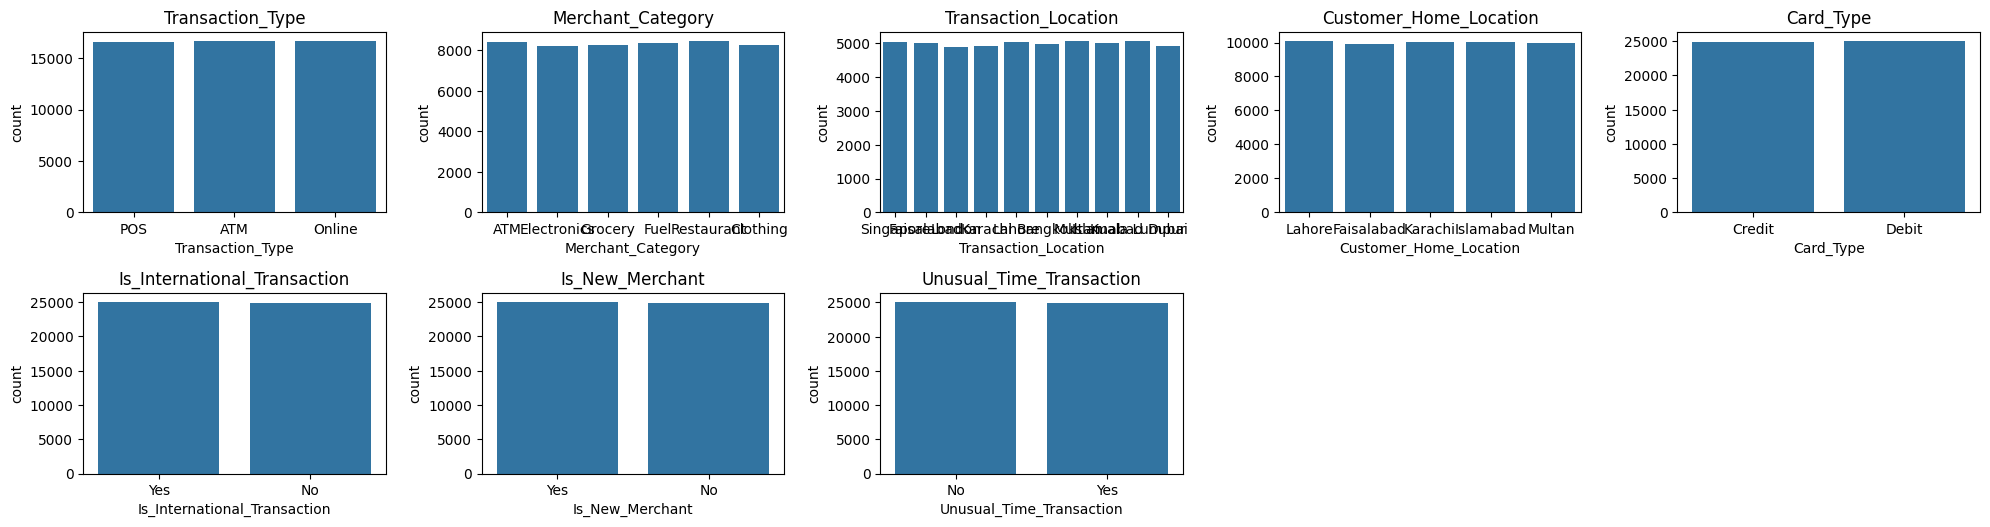

In [30]:
fig = plt.figure(figsize=(20,18))

for i in range(len(cat_cols)):
    ax = fig.add_subplot(7, 5, i+1)
    sns.countplot(x=X[cat_cols].iloc[:, i], ax=ax)
    ax.set_title(cat_cols[i])

plt.tight_layout()
plt.show()

Weak separation between fraud and normal transactions was observed.

CORRELATION

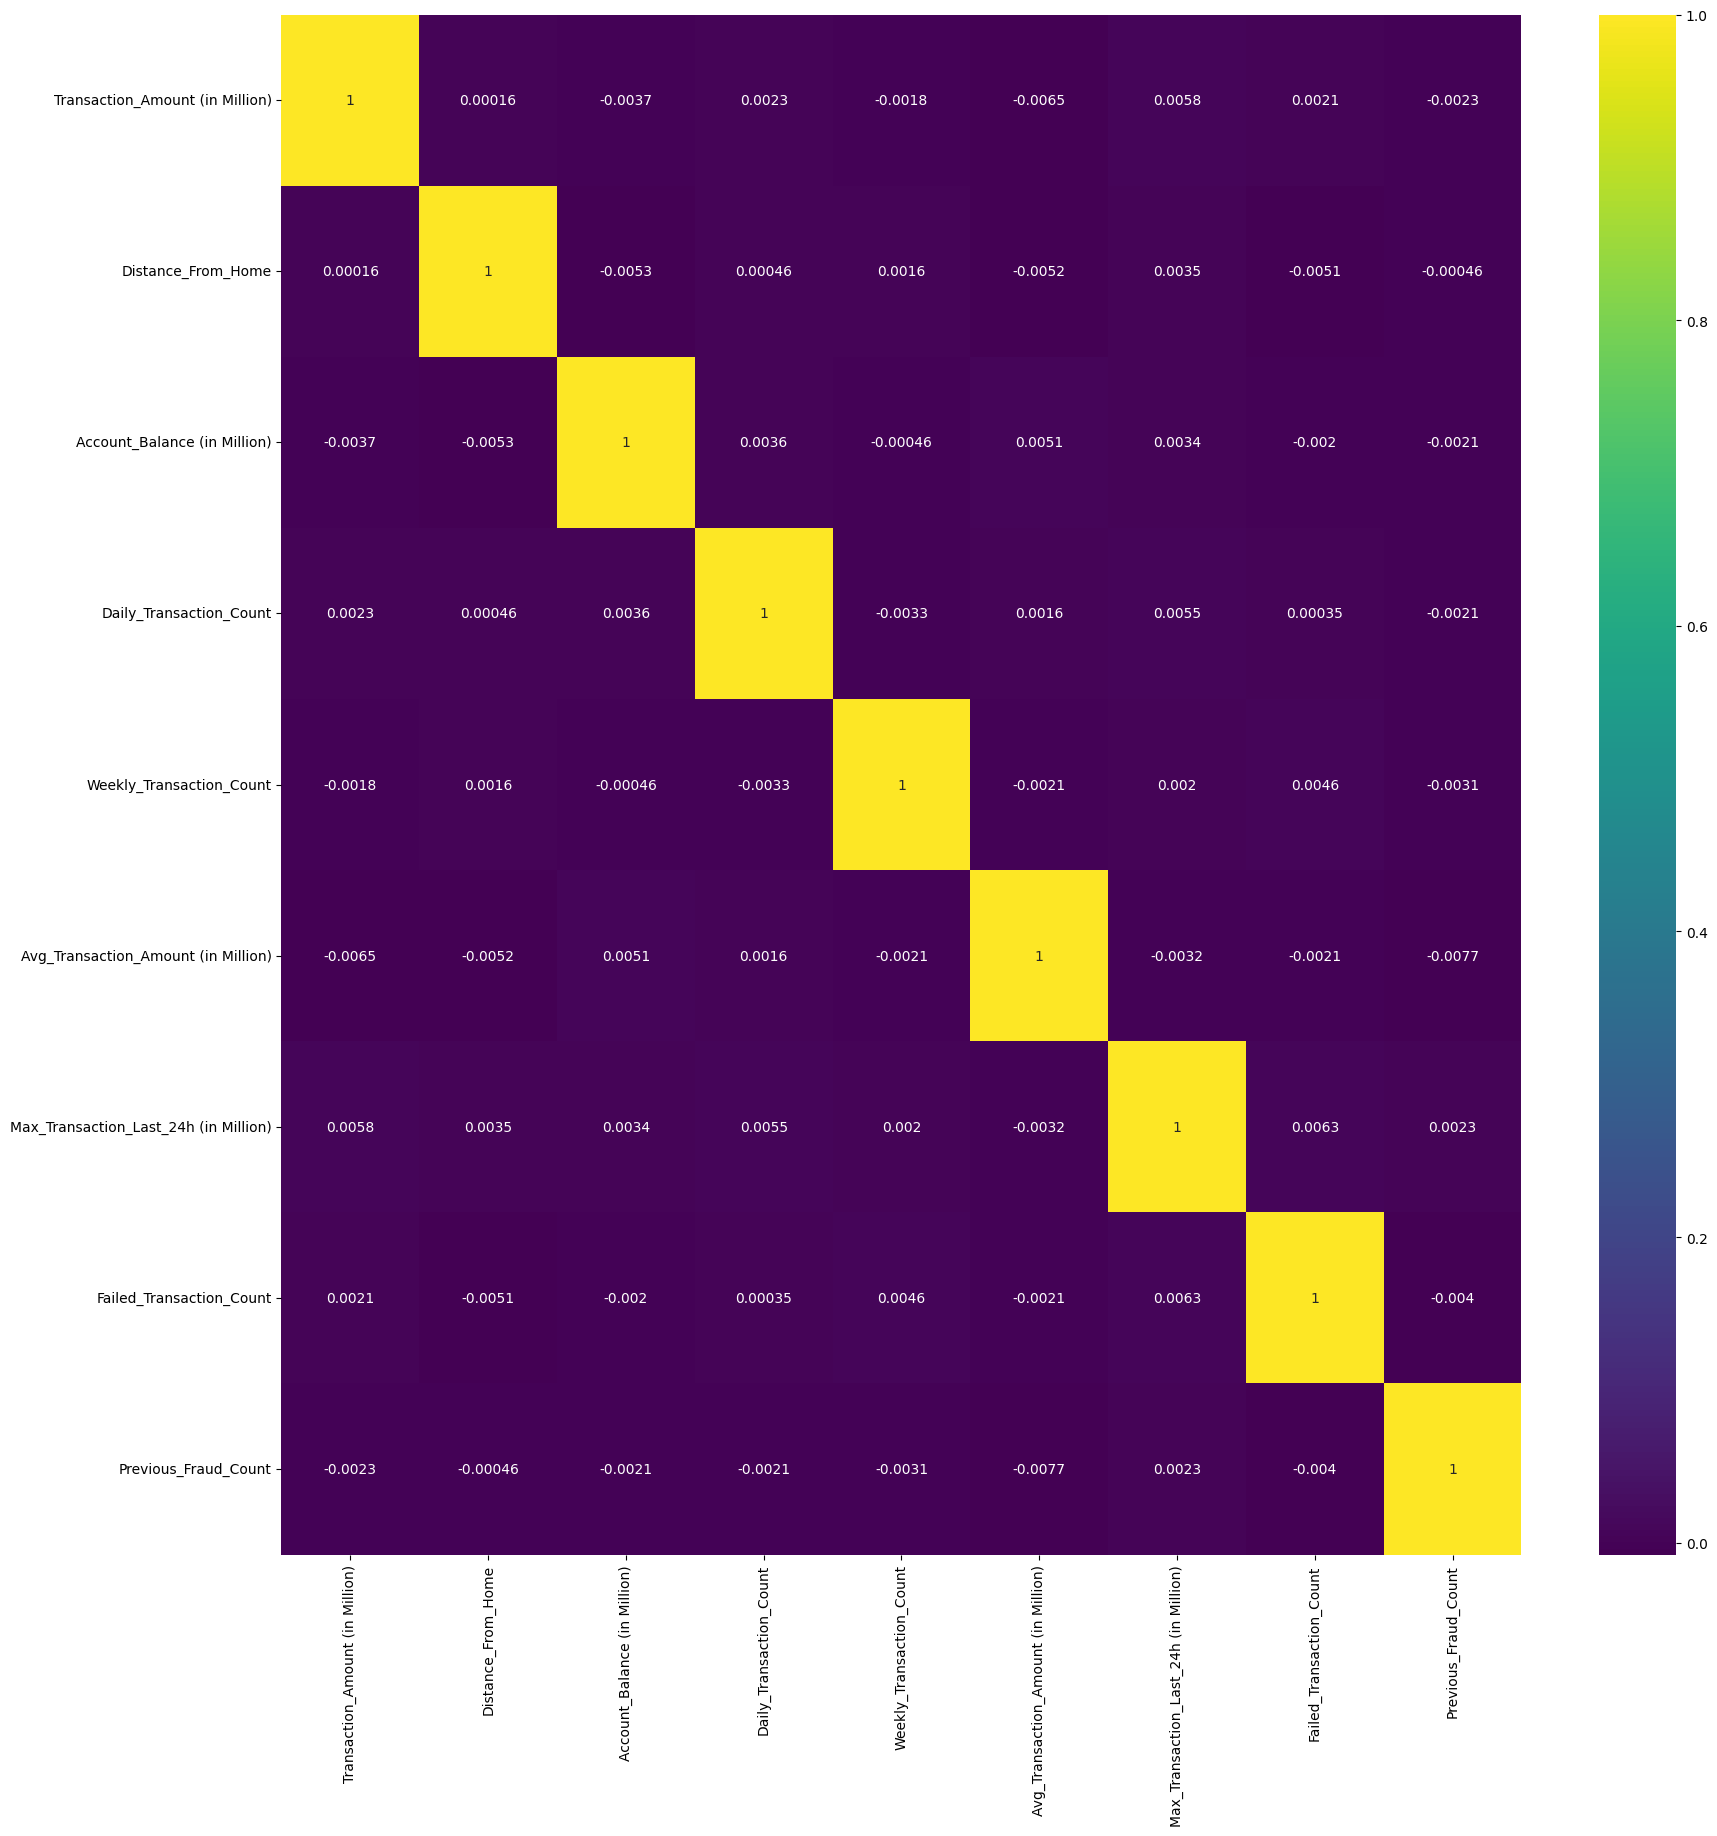

In [31]:
plt.figure(figsize=(20,20))
sns.heatmap(X[num_cols].corr(), annot=True, cmap="viridis")
plt.show()

Weak correlation therefore harder learning problem

Need feature engineering

### TRAIN-TEST SPLIT

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### EDA ON TRAINING DATASET

In [33]:
X_train.isnull().sum().sort_values(ascending=False)

Transaction_Time                         9
Failed_Transaction_Count                 9
Daily_Transaction_Count                  9
Avg_Transaction_Amount (in Million)      8
Transaction_Amount (in Million)          7
Account_Balance (in Million)             7
Merchant_Category                        7
Weekly_Transaction_Count                 5
Is_New_Merchant                          5
Transaction_Location                     5
Is_International_Transaction             4
Transaction_Type                         4
Max_Transaction_Last_24h (in Million)    4
Customer_Home_Location                   4
Transaction_Date                         3
Unusual_Time_Transaction                 3
Card_Type                                3
Distance_From_Home                       2
Previous_Fraud_Count                     2
dtype: int64

In [34]:
#percentage missingness
missing=X.isnull().sum()
percentage=(missing/len(X))*100

missing_table=pd.DataFrame({
    "Missing":missing,
    "Percentage":percentage
})

missing_table=missing_table[missing_table["Missing"]>0]
missing_table.sort_values('Percentage',ascending=False)

,Missing,Percentage
Failed_Transaction_Count,11,0.022002
Transaction_Time,9,0.018001
Transaction_Amount (in Million),9,0.018001
Avg_Transaction_Amount (in Million),9,0.018001
Merchant_Category,9,0.018001
Account_Balance (in Million),9,0.018001
Daily_Transaction_Count,9,0.018001
Transaction_Location,6,0.012001
Weekly_Transaction_Count,5,0.010001
Is_New_Merchant,5,0.010001


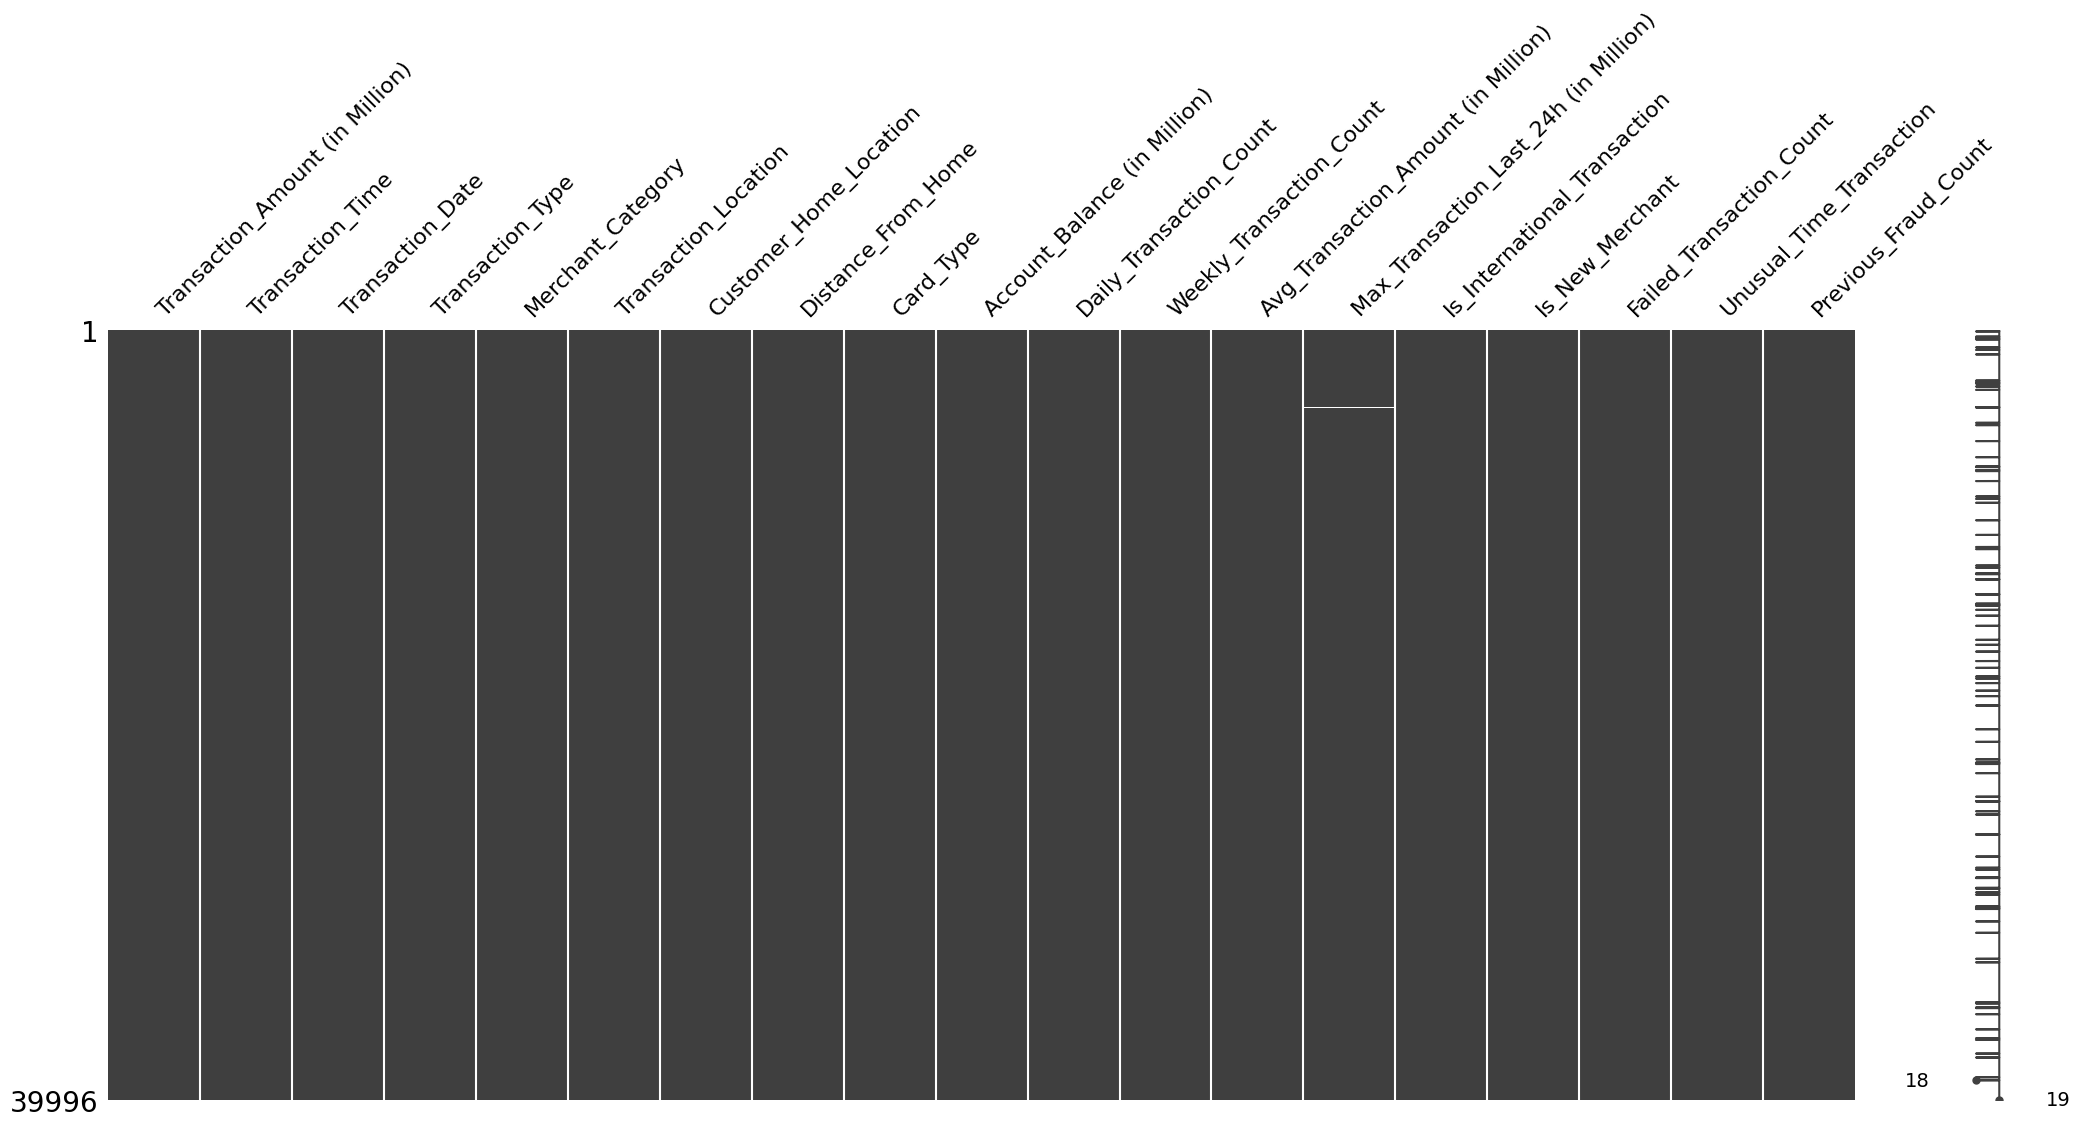

In [35]:
# Missing values
X_train.isnull().sum().sort_values(ascending=False)

mn.matrix(X_train)
plt.show()

### FEATURE ENGINEERING

##### Extract Time-Based Features

In [36]:
# Extract hour (0–23)
X_train["Transaction_Hour"] = X_train["Transaction_Time"].dt.hour

# Extract day of week (0=Monday, 6=Sunday)
X_train["Transaction_Day"] = X_train["Transaction_Date"].dt.dayofweek

# Extract month
X_train["Transaction_Month"] = X_train["Transaction_Date"].dt.month

We are trying to find out At what hour do frauds happen?Are frauds more common on weekends?Are there monthly trends?

Fraud patterns are often time based, transactions happening late night are suspicious while those hapening during weekends are prone to less monitoring

Create Night Transaction Flag

In [37]:
X_train["Night_Transaction"] = X_train["Transaction_Hour"].apply(
    lambda x: 1 if x >= 22 or x <= 5 else 0
)

Fraudsters often operate at night when users are asleep and this feature helps the model detect that behavior

In [38]:
# Drop Original Date Columns
X_train.drop(columns=["Transaction_Time", "Transaction_Date"], inplace=True)

# we droped them because models dont understand raw datetime well

##### BEHAVIORAL FEATURES

Transaction Deviation

In [39]:
X_train["Transaction_Deviation"] = (
    X_train["Transaction_Amount (in Million)"] /
    X_train["Avg_Transaction_Amount (in Million)"]
)

This helps check whether a transaction is unusually large compared to normal.
Fraud transactions are often much higher than usual spending

Transaction Velocity

In [40]:
X_train["Transaction_Velocity"] = (
    X_train["Daily_Transaction_Count"] /
    X_train["Weekly_Transaction_Count"]
)

Helps check the frequecy of transactions. Whether a user is transacting more today compared to other days.
Fraudsters often make many transactions quickly

Transaction vs Balance

In [41]:
X_train["Transaction_Balance_Ratio"] = (
    X_train["Max_Transaction_Last_24h (in Million)"] /
    X_train["Account_Balance (in Million)"]
)

Checking whether the transaction is too big compared to account balance.
Fraud often involves draining accounts

Distance Risk

In [42]:
X_train["Distance_Risk"] = (X_train["Distance_From_Home"] > 200).astype(int)

Checking to see whether the transaction is occuring far away or close to the user.Fraud often occurs in unusual locations

Fraud History

In [43]:
X_train["Fraud_History"] = (
    X_train["Previous_Fraud_Count"] +
    X_train["Failed_Transaction_Count"]
)

Checking whether this user have a risky history.By checking the past behaviour, we are able to predict the future.

Log Transformation (Normalize Amount)

In [44]:
X_train["Log_Transaction_Amount"] = np.log1p(
    X_train["Transaction_Amount (in Million)"]
)

Here, we are reducing the effect of very large transactions so that our data may not be skewed thus helping the model perform better.

Amount vs Balance Ratio

In [45]:
X_train["Amount_to_Balance"] = (
    X_train["Transaction_Amount (in Million)"] /
    (X_train["Account_Balance (in Million)"] + 1)
)

This helps detect unususally large withdrawals

Transactions per Hour

In [46]:
X_train["Txn_per_hour"] = X_train["Daily_Transaction_Count"] / 24

Average activity level so as to detect fraus

High Risk Combination

In [47]:
X_train["High_Risk_Combo"] = (
    (X_train["Night_Transaction"] == 1) &
    (X_train["Distance_Risk"] == 1)
).astype(int)

Is it BOTH night AND far from home?

This is a very strong fraud signal

Feature Engineering on test data

To ensure consistency. The model must see the same features during training and testing. Any transformation applied to training data must also be applied to test data to avoid data leakage and ensure reliable predictions

In [48]:

# Extract Time Features
X_test["Transaction_Hour"] = X_test["Transaction_Time"].dt.hour
X_test["Transaction_Day"] = X_test["Transaction_Date"].dt.dayofweek
X_test["Transaction_Month"] = X_test["Transaction_Date"].dt.month



# Night Transaction 
X_test["Night_Transaction"] = X_test["Transaction_Hour"].apply(
    lambda x: 1 if x >= 22 or x <= 5 else 0
)



#  Drop Original Columns
X_test.drop(columns=["Transaction_Time", "Transaction_Date"], inplace=True)


#  Transaction Deviation
X_test["Transaction_Deviation"] = (
    X_test["Transaction_Amount (in Million)"] /
    X_test["Avg_Transaction_Amount (in Million)"]
)



# Transaction Velocity

X_test["Transaction_Velocity"] = (
    X_test["Daily_Transaction_Count"] /
    X_test["Weekly_Transaction_Count"]
)



# Transaction vs Balance
X_test["Transaction_Balance_Ratio"] = (
    X_test["Max_Transaction_Last_24h (in Million)"] /
    X_test["Account_Balance (in Million)"]
)



# Distance Risk
X_test["Distance_Risk"] = (
    X_test["Distance_From_Home"] > 200
).astype(int)



# Fraud History

X_test["Fraud_History"] = (
    X_test["Previous_Fraud_Count"] +
    X_test["Failed_Transaction_Count"]
)



# Log Transformation
X_test["Log_Transaction_Amount"] = np.log1p(
    X_test["Transaction_Amount (in Million)"]
)



# Amount to Balance Ratio
X_test["Amount_to_Balance"] = (
    X_test["Transaction_Amount (in Million)"] /
    (X_test["Account_Balance (in Million)"] + 1)
)


#  Transactions per Hour
X_test["Txn_per_hour"] = (
    X_test["Daily_Transaction_Count"] / 24
)



#  High Risk Combination

X_test["High_Risk_Combo"] = (
    (X_test["Night_Transaction"] == 1) &
    (X_test["Distance_Risk"] == 1)
).astype(int)

In [49]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 39996 entries, 27986 to 14734
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_Amount (in Million)        39989 non-null  float64
 1   Transaction_Type                       39992 non-null  str    
 2   Merchant_Category                      39989 non-null  str    
 3   Transaction_Location                   39991 non-null  str    
 4   Customer_Home_Location                 39992 non-null  str    
 5   Distance_From_Home                     39994 non-null  float64
 6   Card_Type                              39993 non-null  str    
 7   Account_Balance (in Million)           39989 non-null  float64
 8   Daily_Transaction_Count                39987 non-null  float64
 9   Weekly_Transaction_Count               39991 non-null  float64
 10  Avg_Transaction_Amount (in Million)    39988 non-null  float64
 11  Max_Transactio

### PREPROCESSING

In [50]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(include=np.number).columns

C:\Users\mburu\AppData\Local\Temp\ipykernel_26336\774227395.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns


Imputation (ONLY FIT ON TRAIN)

In [51]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

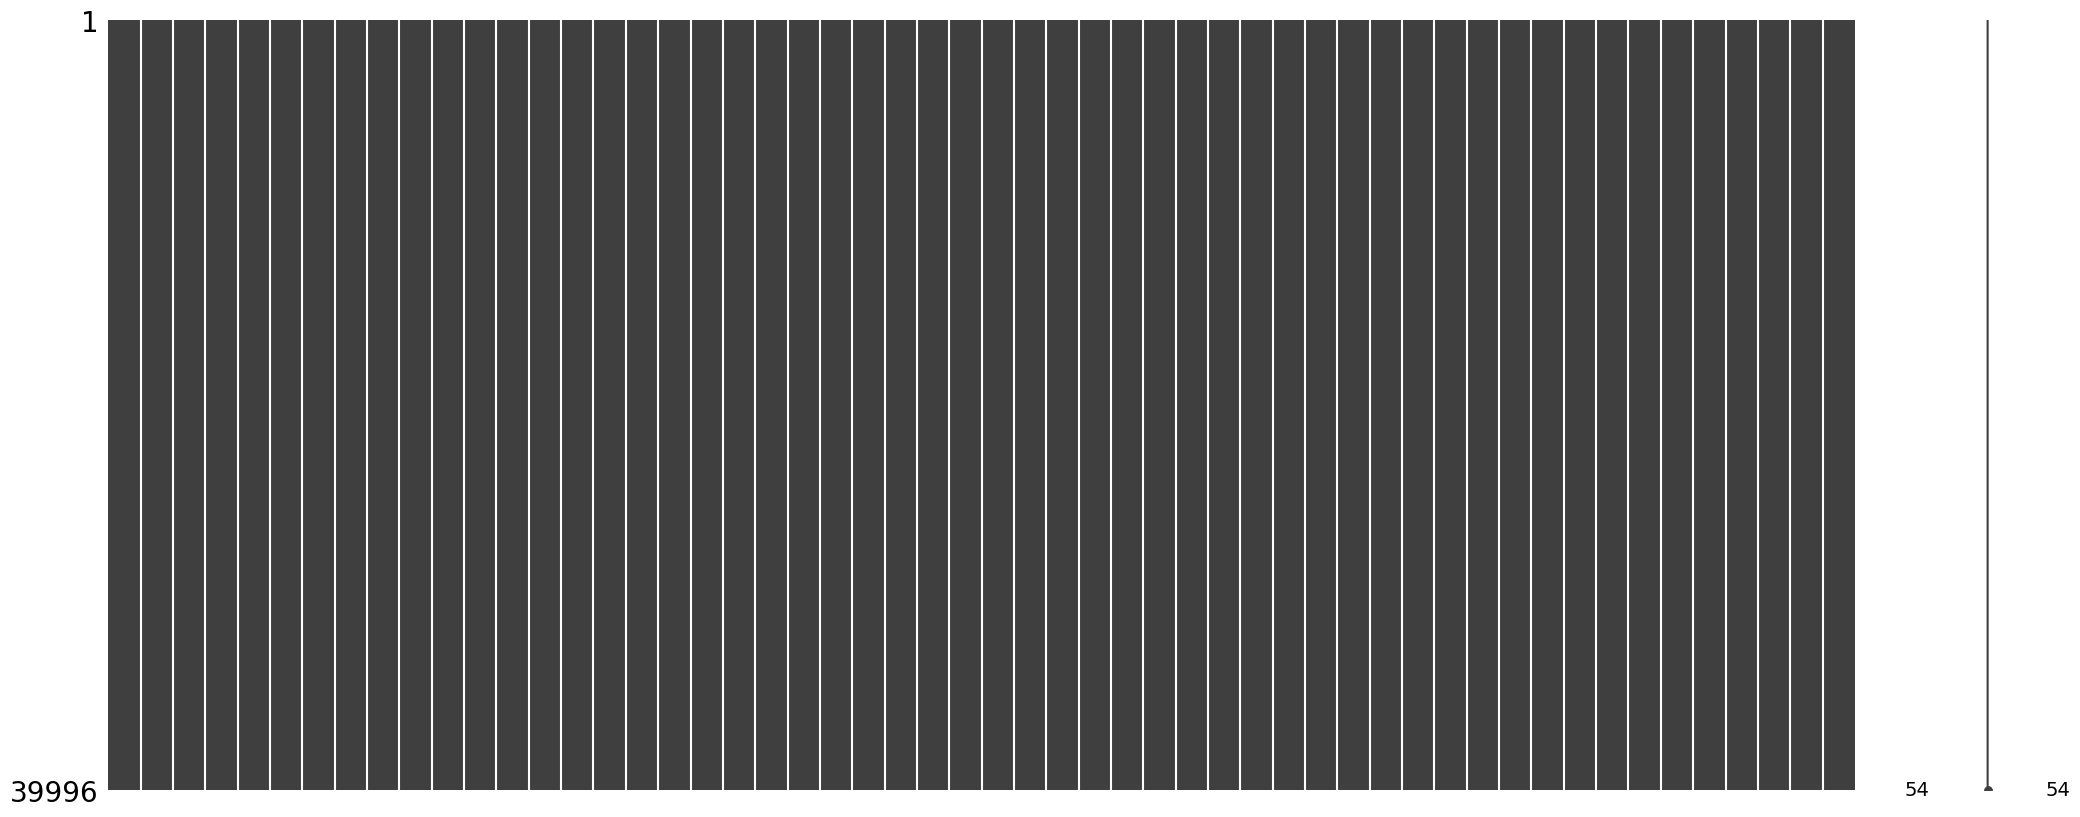

In [86]:
X_train.isnull().sum().sort_values(ascending=False)

mn.matrix(X_train)
plt.show()

Encoding

In [52]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_train = ohe.fit_transform(X_train[cat_cols])
encoded_test = ohe.transform(X_test[cat_cols])

encoded_train = pd.DataFrame(encoded_train, columns=ohe.get_feature_names_out(cat_cols))
encoded_test = pd.DataFrame(encoded_test, columns=ohe.get_feature_names_out(cat_cols))

In [53]:
#Combine
X_train = pd.concat([X_train[num_cols].reset_index(drop=True), encoded_train], axis=1)
X_test = pd.concat([X_test[num_cols].reset_index(drop=True), encoded_test], axis=1)

### HANDLE IMBALANCE

C:\Users\mburu\AppData\Local\Temp\ipykernel_26336\948335681.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="viridis")


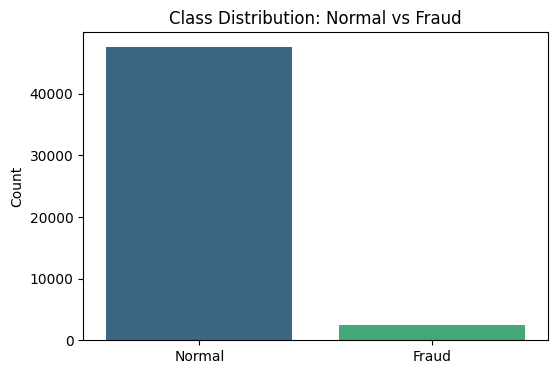

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x=y, palette="viridis")

plt.xticks([0,1], ["Normal", "Fraud"])
plt.xlabel("")
plt.ylabel("Count")
plt.title("Class Distribution: Normal vs Fraud")

plt.show()


In [55]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Apply SMOTE BEFORE scaling
X_res, y_res = smote.fit_resample(X_train, y_train)

Models predicting mostly Normal transactions i.ehigh accuracy but poor fraud detection.

To address this, SMOTE (Synthetic Minority Oversampling Technique) was used before scaling, generating synthetic fraud samples to balance classes.

SCALING

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

In [107]:
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

StandardScaler applied after SMOTE to prevent data leakage.

### MODEL BUILDING

I trained multiple models using fbeta_score(beta=2) to emphasize recall (detecting fraud is more important than false positives).

Random Forest 

In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import fbeta_score , make_scorer


rf = RandomForestClassifier(n_estimators=50, random_state=42) 
f2_scorer = make_scorer(fbeta_score, beta=2)
scores = cross_val_score(
    rf,            
    X_res,       
    y_res.values.ravel(),        
    cv=5,         
    scoring=f2_scorer
)
print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.78422685 1.         1.         1.         1.        ]
Mean Fbeta score: 0.956845369960124


AdaBoostClassifier

In [97]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

scores = cross_val_score(
    ada,
    X_res,
    y_res.values.ravel(),
    cv=5,
    scoring=f2_scorer
)

print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.77779627 0.99252317 0.99305062 0.99452747 0.99294607]
Mean Fbeta score: 0.9501687183003391


XG BOOST

In [66]:
from xgboost import XGBClassifier

scale_weight = len(y_train) / sum(y_train)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)
f2_scorer = make_scorer(fbeta_score, beta=2)

scores = cross_val_score(
    xgb,
    X_res,
    y_res.values.ravel(),
    cv=5,
    scoring=f2_scorer
)

print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")



Cross-validated Fbeta scores: [0.78352628 0.94704228 0.94527796 0.94603664 0.94766197]
Mean Fbeta score: 0.9139090259793672


### MODEL EVALUATION

#### Selecting the best performing candidate model
When it comes to choosing the best candidate model in classification tasks, it is not enough to rely on one single metric like recall, precision etc...(But please note, the choice in evaluation metric should align with the business case). For classification, we take it a step further and look at the model performance per class- in this case, I want a model that is really good at identifying fraudsters- this is the actual business value of the ML model.

So we print the classification report of each model and see how good they are at minimizing false negative and then use the ROC-AUC curve to choose the best performing model.

In [98]:
from sklearn.metrics import classification_report

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_res, y_res)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Random Forest
              precision    recall  f1-score   support

           0       0.96      0.53      0.69      9515
           1       0.06      0.61      0.11       485

    accuracy                           0.54     10000
   macro avg       0.51      0.57      0.40     10000
weighted avg       0.92      0.54      0.66     10000



c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(



AdaBoost
              precision    recall  f1-score   support

           0       0.96      0.74      0.83      9515
           1       0.07      0.39      0.12       485

    accuracy                           0.72     10000
   macro avg       0.52      0.56      0.48     10000
weighted avg       0.92      0.72      0.80     10000


XGBoost
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      9515
           1       0.05      0.21      0.08       485

    accuracy                           0.78     10000
   macro avg       0.50      0.51      0.48     10000
weighted avg       0.91      0.78      0.84     10000



ROC CURVE

c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


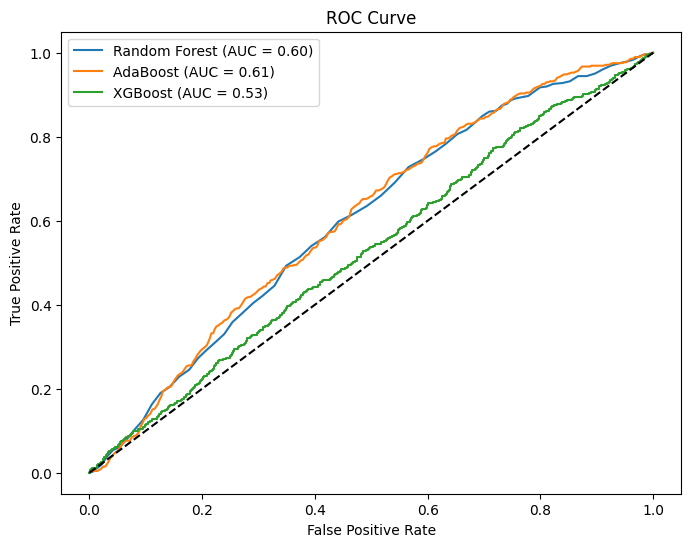

In [99]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

After evaluating multiple models (Logistic Regression, AdaBoost, XGBoost, and Random Forest) using F2-score (recall-focused) and classification reports:

Random Forest provided:

Strong recall (fraud detection ability)

Better balance between precision and recall

More stable predictions across folds

Less overfitting compared to boosting models

### HYPERPARAMETER TUNING 

In [72]:
xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 6,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 300,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 20.637770897832816,
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [112]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[8,12],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='recall',   # focus on fraud detection
    cv=3,
    n_jobs=-1
)

grid.fit(X_res, y_res)

best_rf = grid.best_estimator_

Trying different combinations and finding the one that detects most fraud

### FINAL EVALUATION

              precision    recall  f1-score   support

           0       0.96      0.63      0.76      9515
           1       0.07      0.53      0.12       485

    accuracy                           0.63     10000
   macro avg       0.52      0.58      0.44     10000
weighted avg       0.92      0.63      0.73     10000

AUC: 0.6081475261524126


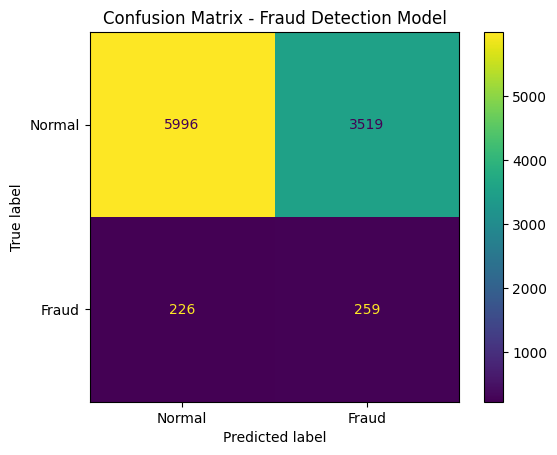

In [113]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred))

# AUC
from sklearn.metrics import roc_auc_score
print("AUC:", roc_auc_score(y_test, y_prob))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - Fraud Detection Model")
plt.show()

The model achieves a recall of 53%, meaning it detects about half of fraudulent transactions, which is important from a risk perspective. However, the precision is very low at 7%, indicating a high number of false positives. This suggests that while the model is sensitive to fraud, it lacks specificity and would generate too many false alerts in a real-world system."

Additionally, the AUC score of 0.61 shows that the model has limited ability to distinguish between fraud and normal transactions, likely due to weak feature separation in the dataset.

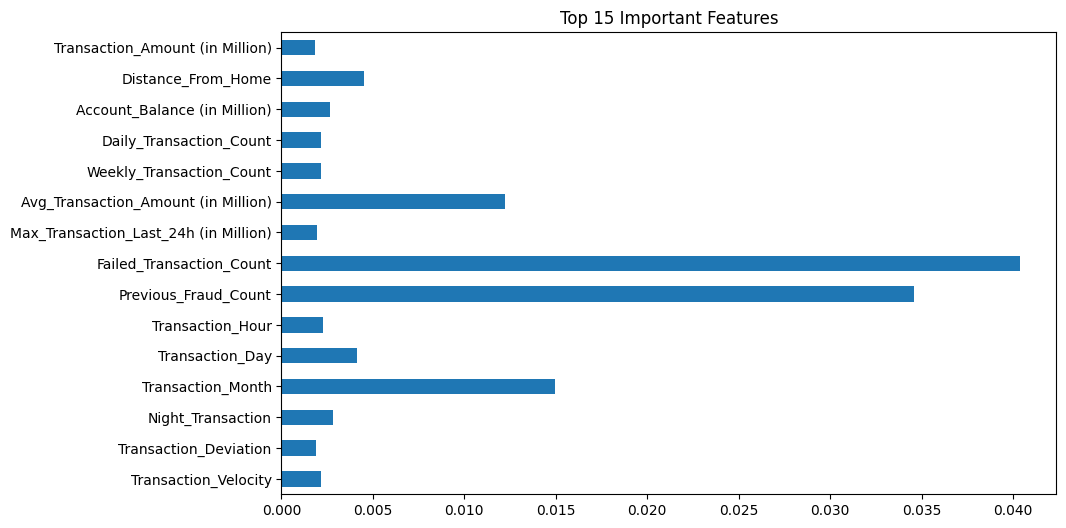

In [114]:


feature_names = X_train.columns

feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=False).head(15)

# Plot top 15
plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='barh')
plt.title("Top 15 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [115]:
print(feat_imp)

Transaction_Amount (in Million)          0.001844
Distance_From_Home                       0.004499
Account_Balance (in Million)             0.002630
Daily_Transaction_Count                  0.002177
Weekly_Transaction_Count                 0.002173
Avg_Transaction_Amount (in Million)      0.012205
Max_Transaction_Last_24h (in Million)    0.001968
Failed_Transaction_Count                 0.040355
Previous_Fraud_Count                     0.034575
Transaction_Hour                         0.002250
Transaction_Day                          0.004114
Transaction_Month                        0.014966
Night_Transaction                        0.002820
Transaction_Deviation                    0.001893
Transaction_Velocity                     0.002169
Transaction_Balance_Ratio                0.002359
Distance_Risk                            0.000399
Fraud_History                            0.024878
Log_Transaction_Amount                   0.001833
Amount_to_Balance                        0.002275


### SAVE MODEL

In [116]:
import pickle

with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

#### Recommendations

##### Feature Engineering

Add features like:

Merchant category

Device/IP fingerprinting

Historical account patterns

Time since last transaction

Fraud patterns are complex and require nuanced behavioral signals.

##### Model Ensemble

Consider combining Logistic Regression (high recall) with RF for better fraud detection.

##### Data Enrichment

If possible, gather more real fraud samples.

Synthetic SMOTE data helps but may not fully capture fraud patterns.

##### Regular Monitoring

Fraud patterns evolve, so retrain models periodically.

Monitor FN rate and adjust features/thresholds.